# 1. The PSD is part of the likelihood

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**

> Designed for Google Colab. Run top to bottom; **Extension** sections may be skipped live.


## Learning goals

Distinguish PSD from ASD, estimate a PSD with Welch averaging, whiten a residual, and explain the Whittle likelihood.

\[
\log p(d\mid\theta,S_n)=-\tfrac12(d-h\mid d-h)-\tfrac12\sum_k\log S_n(f_k)+C,
\quad (a\mid b)=4\mathrm{Re}\sum_k\frac{\tilde a_k\tilde b_k^*}{S_n(f_k)}\Delta f.
\]

The PSD is not decorative: it says which residuals are surprising. The normalisation is constant only while the PSD is fixed.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
rng = np.random.default_rng(20260817)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["animation.html"] = "jshtml"
print("Running in Colab:", IN_COLAB)

Running in Colab: False


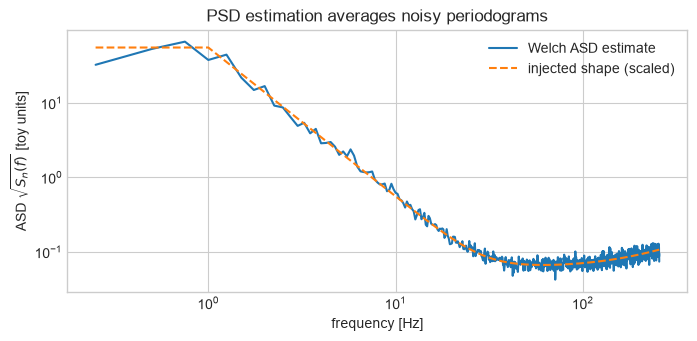

In [2]:
from scipy.signal import welch
sample_rate, duration = 512, 64
time = np.arange(0, duration, 1/sample_rate)
frequency = np.fft.rfftfreq(time.size, 1/sample_rate)
target_shape = 1 + (30/np.maximum(frequency, 1))**4 + (frequency/180)**2
white = rng.normal(size=time.size)
noise = np.fft.irfft(np.fft.rfft(white)*np.sqrt(target_shape), n=time.size)
f_welch, psd_hat = welch(noise, fs=sample_rate, nperseg=2048, average="median")
target_asd = np.sqrt(np.interp(f_welch, frequency, target_shape))
target_asd *= np.median(np.sqrt(psd_hat[20:])/target_asd[20:])
fig, ax = plt.subplots(figsize=(8,3.4))
ax.loglog(f_welch[1:], np.sqrt(psd_hat[1:]), label="Welch ASD estimate")
ax.loglog(f_welch[1:], target_asd[1:], "--", label="injected shape (scaled)")
ax.set(xlabel="frequency [Hz]", ylabel=r"ASD $\sqrt{S_n(f)}$ [toy units]",
       title="PSD estimation averages noisy periodograms"); ax.legend(); plt.show()

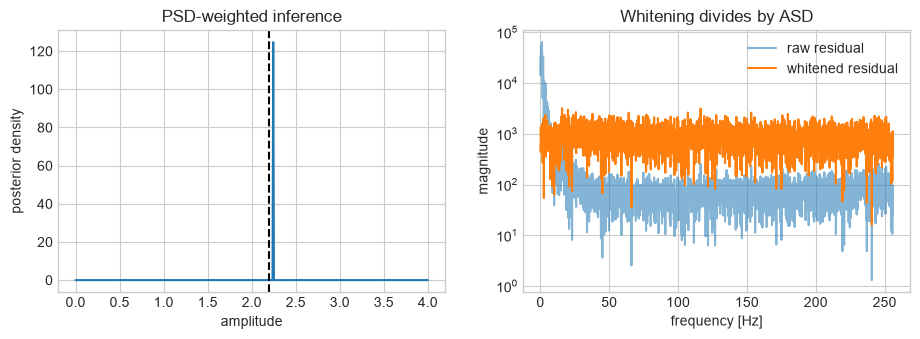

Injected 2.20; MAP 2.24


In [3]:
analysis_duration = 8; n = analysis_duration*sample_rate
t = time[:n]; d = noise[:n].copy()
true_amplitude, signal_frequency = 2.2, 45.0
template = np.sin(2*np.pi*signal_frequency*t + .3); d += true_amplitude*template
f = np.fft.rfftfreq(n, 1/sample_rate); df = f[1]-f[0]
Sn = np.interp(f, f_welch, psd_hat); Sn[0] = Sn[1]
d_f = np.fft.rfft(d)
def log_likelihood(amplitude):
    r = d_f-np.fft.rfft(amplitude*template)
    return -2*df*np.sum(np.abs(r)**2/Sn)
grid=np.linspace(0,4,500); logp=np.array([log_likelihood(a) for a in grid])
p=np.exp(logp-logp.max()); p/=np.trapezoid(p,grid); best=grid[np.argmax(p)]
r=d_f-np.fft.rfft(best*template)
fig,axes=plt.subplots(1,2,figsize=(11,3.4))
axes[0].plot(grid,p); axes[0].axvline(true_amplitude,color="k",ls="--")
axes[0].set(xlabel="amplitude",ylabel="posterior density",title="PSD-weighted inference")
axes[1].semilogy(f[1:],np.abs(r[1:]),alpha=.55,label="raw residual")
axes[1].semilogy(f[1:],np.abs(r[1:])/np.sqrt(Sn[1:]),label="whitened residual")
axes[1].set(xlabel="frequency [Hz]",ylabel="magnitude",title="Whitening divides by ASD"); axes[1].legend(); plt.show()
print(f"Injected {true_amplitude:.2f}; MAP {best:.2f}")

## Exercise and boundary

Replace `Sn` by a constant, then underestimate it near 45 Hz. Which bins dominate and why does the posterior become overconfident?

This example assumes stationary Gaussian noise, independent Fourier bins, a fixed PSD, and no glitches or calibration uncertainty. Those are modelling assumptions, not guarantees supplied by a Fourier transform.